# Sistema de Predicción de Riesgo de Diabetes

## Importar librerías

In [25]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE


In [26]:
#instalando libra de balanceo
#!pip install imbalanced-learn

## Cargando tabla

In [27]:
health_ind = pd.read_csv("archive/raw/diabetes_012_health_indicators_BRFSS2015.csv")

In [28]:
health_ind.head(3)

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0


#### Cantidad de datos iniciales:
rows = 253680\
columns = 22

#### Significado de las columnas:

-> Características clave:
- Diabetes_012 = Estado de diabetes (Target)
    * 0 = No diabetes
    * 1 = Prediabetes
    * 2 = Diabetes
- HighBP: Diagnóstico de presión arterial alta.
- HighChol: Diagnóstico de colesterol alto.
- CholCheck: Si la persona se ha realizado un control de colesterol en los últimos 5 años.
- BMI: Índice de masa corporal.
- Stroke: Ha tenido un derrame cerebral.
- HeartDiseaseorAttack: Ha tenido enfermedad coronaria o ataque cardíaco.

-> Lifestyle:
- Smoker: Ha fumado al menos 100 cigarrillos en su vida.
- PhysActivity: Realizó actividad física en los últimos 30 días (excluyendo trabajo).
- Fruits: Consume fruta al menos una vez al día.
- Veggies: Consume vegetales al menos una vez al día.
- HvyAlcoholConsump: Consumo elevado de alcohol (definido según umbrales del CDC).

-> Healthcare access:
- AnyHealthcare: Tiene algún tipo de cobertura médica.
- NoDocbcCost: No visitó al médico por razones económicas.

-> General Health:
- GenHlth: Percepción general de salud:
    * 1 = Excelente
    * 2 = Muy buena
    * 3 = Buena 
    * 4 = Regular 
    * 5 = Mala
- MentHlth: Número de días en los últimos 30, con mala salud mental.
- PhysHlth: Número de días en los últimos, 30 con mala salud física.
- DiffWalk: Tiene dificultad para caminar o subir escaleras.

-> Demographic Variable:
- Sex:
    * 0 = Mujer
    * 1 = Hombre
- Age: Categoría de edad (codificada en rangos; no es edad exacta).
- Education: Nivel educativo (categorías ordinales crecientes).
- Income: Categoria de ingreso anual (ordinal).



Glucosa alterada en ayunas, puede decirse que es una prediabetes 

diabeticos tipo 1, son lo que nacen con ellos, en la infancia, muy jovenes y necestian insulina desde el inicio, y no es reversible.


## Limpieza

### Inspección de valores nulos

In [29]:
health_ind.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

### Cambio de tipo de datos

In [30]:
# Variables binarias
binary_cols = [
    "HighBP","HighChol","CholCheck","Smoker","Stroke",
    "HeartDiseaseorAttack","PhysActivity","Fruits",
    "Veggies","HvyAlcoholConsump","AnyHealthcare",
    "NoDocbcCost","DiffWalk","Sex"
]
health_ind[binary_cols] = health_ind[binary_cols].astype("int8")

# Variables ordinales
ordinal_cols = ["GenHlth","Age","Education","Income", "Diabetes_012"]
health_ind[ordinal_cols] = health_ind[ordinal_cols].astype("int8")

### Busque de Duplicados y su Eliminación

In [31]:
# observacion de duplicados
health_ind.duplicated().sum()

#Eiminación de duplicados 
health_ind = health_ind.drop_duplicates()

### Observación de mi variable Target -> Diabetes_012

Diabetes_012
0    190055
2     35097
1      4629
Name: count, dtype: int64


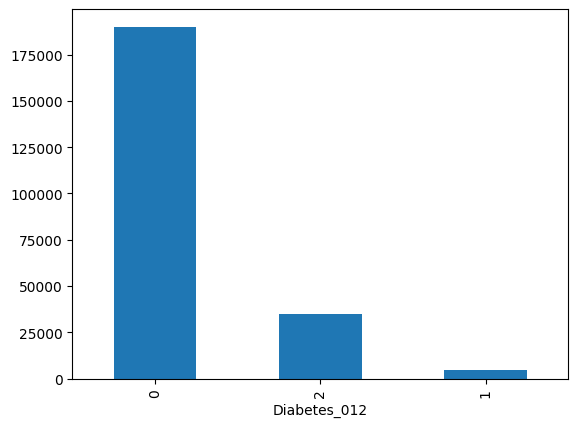

In [32]:
#Observacion del balanceo de mi columna objectivo
target = health_ind['Diabetes_012'].value_counts()
print(target)
target.plot(kind='bar')
plt.show()

Como estos valores de Diabetes 2 y 1, hay mucha diferencia con los que no tienen diabetes, para tener más valores en diabetes, uniré pre-diabetes con diabetes como persona de riesgo.

In [33]:
# Me creo una columna Risk_group para agrupar si son diabeticos o no
health_ind["Risk_Group"] = health_ind["Diabetes_012"].apply(lambda x: 0 if x == 0 else 1)
health_ind["Risk_Group"].value_counts(normalize=True)

Risk_Group
0    0.827114
1    0.172886
Name: proportion, dtype: float64

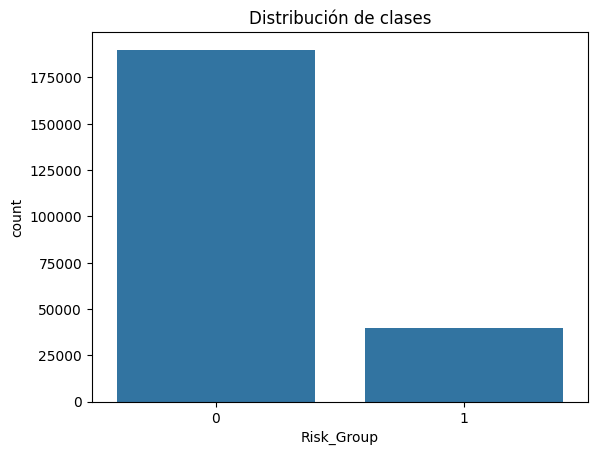

In [34]:
# Gráfico la nueva columna que solo tendra 0 -> No diabetes y 1 -> Diabetes
target = health_ind['Risk_Group'].value_counts()
sns.countplot(x="Risk_Group", data=health_ind)
plt.title("Distribución de clases")
plt.show()


In [35]:
#Quiero ver como se comporta cada variable
health_ind.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_012,229781.0,0.325627,0.724623,0.0,0.0,0.0,0.0,2.0
HighBP,229781.0,0.454441,0.497921,0.0,0.0,0.0,1.0,1.0
HighChol,229781.0,0.441760,0.496598,0.0,0.0,0.0,1.0,1.0
CholCheck,229781.0,0.959535,0.197047,0.0,1.0,1.0,1.0,1.0
BMI,229781.0,28.685670,6.786360,12.0,24.0,27.0,32.0,98.0
Smoker,229781.0,0.465661,0.498821,0.0,0.0,0.0,1.0,1.0
Stroke,229781.0,0.044756,0.206767,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,229781.0,0.103216,0.304241,0.0,0.0,0.0,0.0,1.0
PhysActivity,229781.0,0.733355,0.442206,0.0,0.0,1.0,1.0,1.0
Fruits,229781.0,0.612966,0.487073,0.0,0.0,1.0,1.0,1.0


* Variable objetivo: Risk_Group
    - Mean = 0.1729
    - Eso significa ≈ 17.3% clase positiva.
    - Confirmación clara de desbalance.
    - La mediana es 0 → la mayoría no está en riesgo.

* Variables binarias:
    - HighBP = 0.454 → 45.4% hipertensión.
    - HighChol = 0.441 → 44.1% colesterol alto.
    - Stroke = 0.044 → 4.4% derrame.
    - HeartDiseaseorAttack = 0.103 → 10.3%.
    - HvyAlcoholConsump = 0.060 → 6%.
    - AnyHealthcare = 0.946 → casi todos tienen cobertura.

Variables muy desbalanceadas (como Stroke, HvyAlcoholConsump) pueden tener menor poder predictivo o generar ruido.

* BMI (numérica real)
    - Media ≈ 28.7
    - Mediana = 27
    - Q3 = 32
    - Máx = 98

Conclusiones:
- La población promedio está en sobrepeso.
- Hay outliers extremos (98).
- Distribución sesgada a la derecha.

Probablemente variable importante para el modelo.

* MentHlth y PhysHlth
    - Mediana = 0
	- Q3 bajo (2 y 4)
	- Máximo = 30

Distribución fuertemente asimétrica.\
Muchos ceros → variable cero-inflada.

* GenHlth
	- Media ≈ 2.6
	- Mediana = 3

Mayoría percibe salud entre buena y muy buena.\
Es ordinal, no continua.

* Age
	- Media ≈ 8 (categoría)
	- Rango 1–13

No es edad real. Es rango categórico.

* Education e Income
	- Distribución concentrada en categorías medias-altas.
	- Variables ordinales, no continuas.


Conclusiones:
1.	Dataset grande (230k registros).
2.	Target desbalanceado (~17%).
3.	BMI tiene variabilidad real y outliers.
4.	MentHlth y PhysHlth están sesgadas.
5.	Varias variables binarias están muy concentradas.
6.	Algunas variables pueden tener bajo poder discriminativo.   

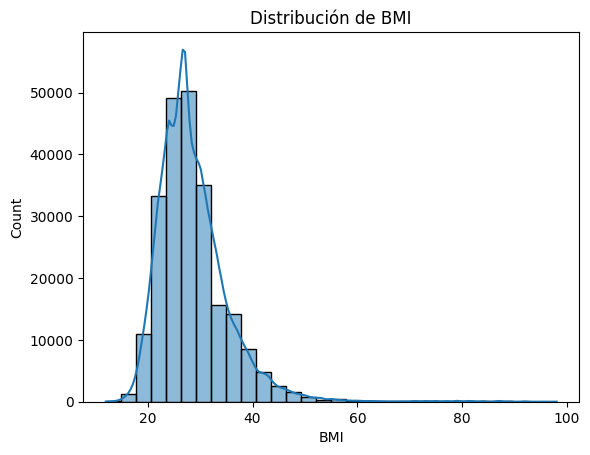

In [12]:
sns.histplot(health_ind["BMI"], bins=30, kde=True)
plt.title("Distribución de BMI")
plt.show()

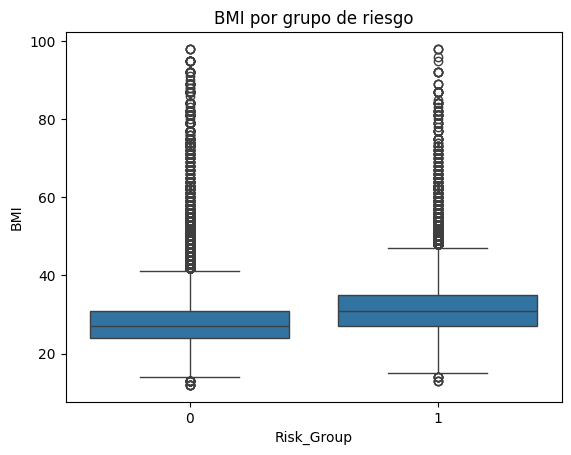

In [13]:
sns.boxplot(x="Risk_Group", y="BMI", data=health_ind)
plt.title("BMI por grupo de riesgo")
plt.show()

Las personas en el grupo de riesgo tienden a tener mayor BMI.\
Es consistente con la literatura médica: mayor IMC → mayor probabilidad de diabetes tipo 2.

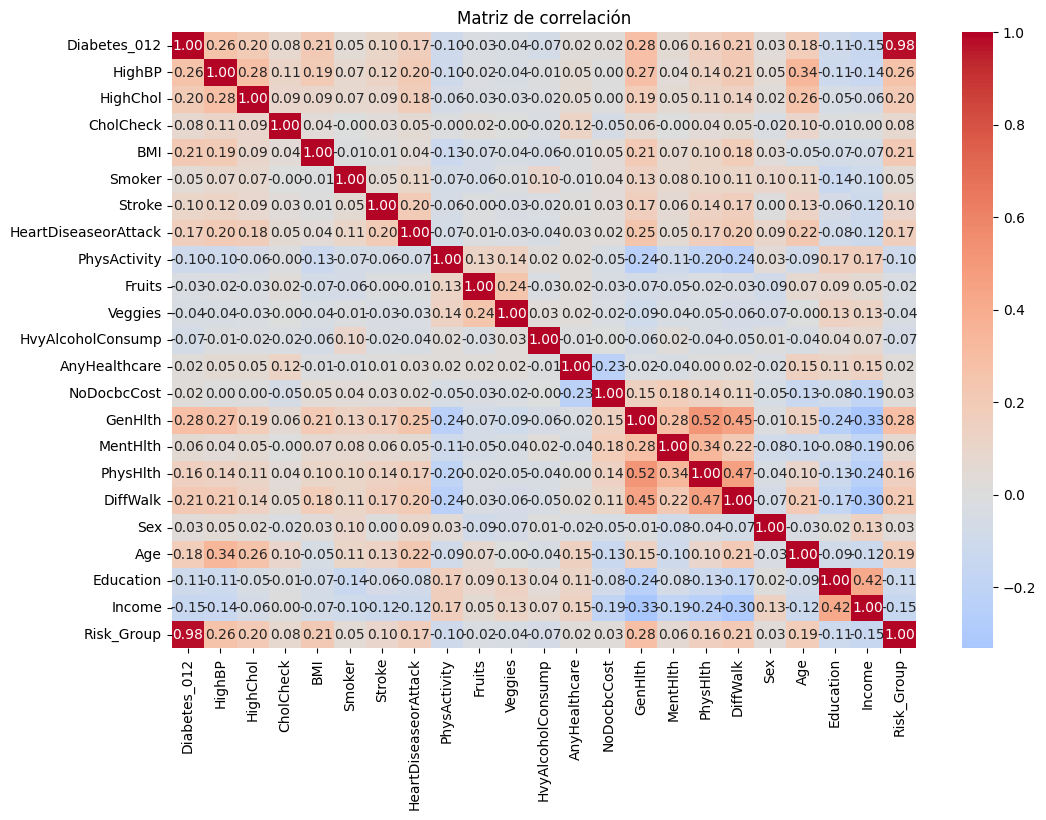

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(health_ind.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

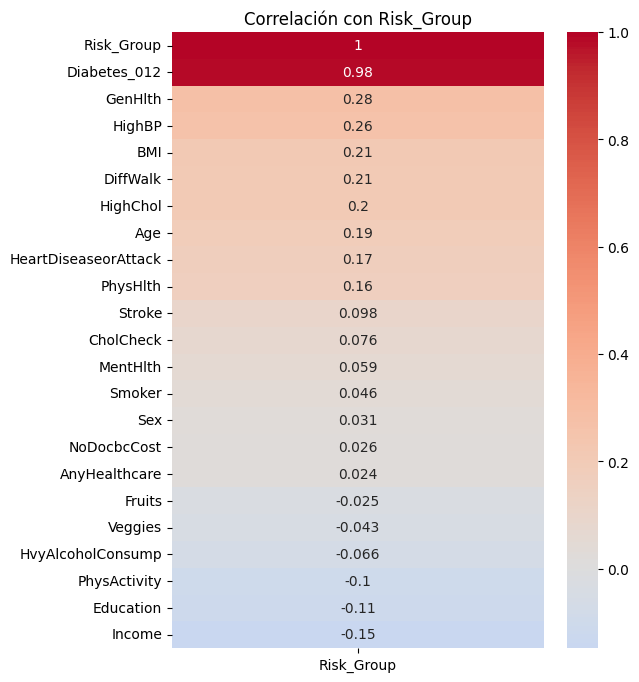

In [19]:
corr_target = health_ind.corr()["Risk_Group"].sort_values(ascending=False)

plt.figure(figsize=(6,8))
sns.heatmap(corr_target.to_frame(), 
            annot=True, 
            cmap="coolwarm", 
            center=0)
plt.title("Correlación con Risk_Group")
plt.show()

##### Pasando la limpieza a un csv

In [37]:
health_ind.to_csv("archive/processed/diabetes_clean.csv", index=False)

### Train test Split

In [ ]:
# Creando features y target para mi modelo 
features = health_ind.drop(["Diabetes_012","Risk_Group"], axis=1)
target= health_ind["Risk_Group"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    features, 
    target, 
    test_size=0.2, 
    random_state=42)

### Escalando 

In [ ]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns)

### Balanceando variable target

In [ ]:
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_scaled, y_train)

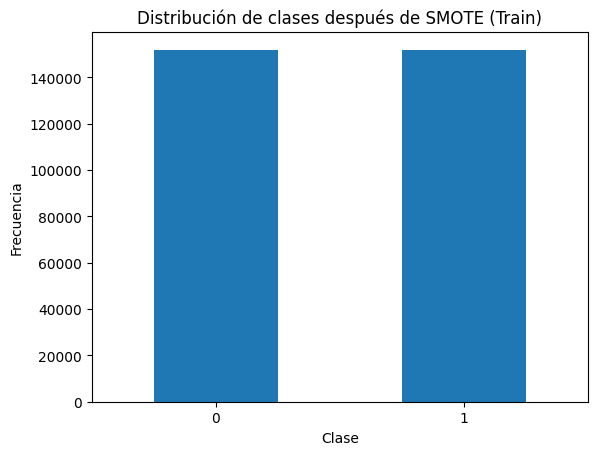

In [ ]:
pd.Series(y_train_bal).value_counts().plot(kind="bar")

plt.title("Distribución de clases después de SMOTE (Train)")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.xticks(rotation=0)
plt.show()

#### Modelo con Knn 

In [ ]:
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_bal, y_train_bal)
    y_pred = knn.predict(X_test)
    print(k, accuracy_score(y_test, y_pred), "Precision", precision_score(y_test, y_pred), "Recall:", recall_score(y_test, y_pred), "F1:", f1_score(y_test, y_pred))

1 0.33751115172879 Precision 0.1712956230914643 Recall: 0.7511796964672873 F1: 0.2789750390754511
2 0.7230454555345214 Precision 0.25780553077609275 Recall: 0.3317178931258768 F1: 0.2901282766313441
3 0.5571077311399787 Precision 0.18659520112207584 Recall: 0.4750669557454406 F1: 0.2679470579772695
4 0.7478077333159258 Precision 0.23750175045511834 Recall: 0.21629894146154827 F1: 0.2264050193565612
5 0.7052462084122114 Precision 0.23721787194841087 Recall: 0.3284019895421502 F1: 0.27545999144201966
6 0.7639967795983201 Precision 0.22815270490320247 Recall: 0.16082132381073844 F1: 0.18865948533812088
7 0.6918423743934548 Precision 0.22840938386182005 Recall: 0.3389873740594312 F1: 0.272923298079885
8 0.7475901386078291 Precision 0.23731656184486374 Recall: 0.21655401096798876 F1: 0.22646038943718325
9 0.724525099549579 Precision 0.2480920020909566 Recall: 0.3026399693916592 F1: 0.2726645984143399
10 0.7332288878734469 Precision 0.24734133790737564 Recall: 0.2758576712154062 F1: 0.260822

In [ ]:
knn = KNeighborsClassifier(n_neighbors=13)


In [ ]:
scores = cross_val_score(knn, X_train_bal, y_train_bal, cv=5)
scores.mean()

0.7841699983653077

In [ ]:
knn.fit(X_train_bal, y_train_bal)

,n_neighbors,13
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [ ]:
pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

print(f"Accuracy es: {accuracy}")
print(f"Precision es: {precision}")
print(f"Recall es: {recall}")
print(f"F1 score es: {f1}")

Accuracy es: 0.7216528494027026
Precision es: 0.2560843432850527
Recall es: 0.3314628236194363
F1 score es: 0.28893829905503055
